In [3]:
import numpy as np
import pandas as pd

In [4]:
# random seed
np.random.seed(42) # ---> seed(42) her seferinde random sayı oluşturduğumuzda aynı sayıyı almamızı sağlar. 42'nin esprisi yok!

set1no = 900
set2no = 100

In [5]:
df1 = pd.DataFrame({
    "feature_1": np.random.normal(loc=0, scale=1, size=set1no), # loc -> ortalama 0 olacak şekilde , scale -> standart sapma 1 olacak şekilde sayılar
    "feature_2": np.random.normal(loc=0, scale=1, size=set1no), # üretir. size -> kaç tane sayı üreteceğimi belirtir!
    "target": [0] * set1no # set1no tane 0 dan oluşan liste üretir!
})

df2 = pd.DataFrame({
    "feature_1": np.random.normal(loc=0, scale=1, size=set2no),
    "feature_2": np.random.normal(loc=0, scale=1, size=set2no),
    "target": [1] * set2no
})

In [6]:
df1.head()

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0


In [7]:
df2.head()

,feature_1,feature_2,target
0,1.901191,0.696954,1
1,-0.060661,-0.333819,1
2,-0.708407,1.173125,1
3,-1.513714,0.369642,1
4,-1.803140,-0.107302,1


In [8]:
df = pd.concat([df1,df2]).reset_index(drop=True)

In [9]:
df

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
995,-0.370011,1.070150,1
996,-0.258796,-0.026521,1
997,1.598647,-0.881875,1
998,0.560919,-0.163067,1


In [10]:
df["target"].unique()

array([0, 1])

In [11]:
df["target"].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [12]:
# upsampling -> upsample minority (azınlıkta olanları arttırmak!)

In [13]:
# downsampling -> downsample majority (çoğunlukta olanı azaltmak!)

In [14]:
#Dengesiz Data Neden Problem?

# 👉 Çünkü model hep baskın sınıfa yönelir.
# 👉 Mesela bir 950 kedi 50 köpek olsun. Örnekte model hep kedi dese %95 doğruluk alır. Ama aslında köpekleri hiç ayırt edememiş olur.
# 👉 Yani accuracy(kesinlik) yüksek gözükür ama model başarısızdır.

# 👉upsampling

In [15]:
df_minority = df[df["target"] == 1]

df_majority = df[df["target"] == 0]

In [16]:
df_minority

,feature_1,feature_2,target
900,1.901191,0.696954,1
901,-0.060661,-0.333819,1
902,-0.708407,1.173125,1
903,-1.513714,0.369642,1
904,-1.803140,-0.107302,1
...,...,...,...
995,-0.370011,1.070150,1
996,-0.258796,-0.026521,1
997,1.598647,-0.881875,1
998,0.560919,-0.163067,1


In [17]:
df_majority

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
895,0.648710,-0.751969,0
896,-0.167118,-0.319054,0
897,0.146714,-0.796026,0
898,1.206509,1.076007,0


In [18]:
from sklearn.utils import resample  #scikit learn kütüphanesini aktifleştiriyoruz!

In [19]:
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42) # upsample işlemi yaptık!

# burada replace = True --> Dataları tekrarlıyor. Çünkü elimizde 100 data var ve 900 e çıkacak bunları havadan almıyor tekrarlayarak alıyor!

In [20]:
df_minority_upsampled

,feature_1,feature_2,target
951,1.775311,1.261922,1
992,-0.436386,1.188913,1
914,-0.268531,-1.801058,1
971,-0.214921,-2.940389,1
960,-0.134309,-0.054894,1
...,...,...,...
952,-1.193637,-0.905732,1
965,-1.662492,0.089581,1
976,-0.562168,1.124113,1
942,-0.548725,0.269127,1


In [21]:
df_upsampled = pd.concat([df_majority,df_minority_upsampled])

In [22]:
df_upsampled

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
952,-1.193637,-0.905732,1
965,-1.662492,0.089581,1
976,-0.562168,1.124113,1
942,-0.548725,0.269127,1


In [23]:
# 1800 satır var dikkat!

In [24]:
df_upsampled["target"].value_counts() # gerçekten de df_minority 100 datadan 900 dataya çıktı!

target
0    900
1    900
Name: count, dtype: int64

In [25]:
df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42) # downsample işlemi yaptık!

# burada replace = False --> Dataları tekrarlamaya gerek yok çünkü elimizde 900 data var ve 100 e düşürülecek 
# bu sebeple data tekrarına gerek yok elimizde yeteri kadar veri var!

In [26]:
df_majority_downsampled

,feature_1,feature_2,target
70,0.361396,0.128104,0
827,-0.522860,0.808058,0
231,0.216459,0.421921,0
588,0.830336,-1.525656,0
39,0.196861,-0.564079,0
...,...,...,...
398,-0.114540,0.267392,0
76,0.087047,-0.452306,0
196,-0.883857,0.078635,0
631,1.529550,-1.768439,0


In [27]:
df_downsampled = pd.concat([df_minority,df_majority_downsampled])

In [28]:
df_downsampled

,feature_1,feature_2,target
900,1.901191,0.696954,1
901,-0.060661,-0.333819,1
902,-0.708407,1.173125,1
903,-1.513714,0.369642,1
904,-1.803140,-0.107302,1
...,...,...,...
398,-0.114540,0.267392,0
76,0.087047,-0.452306,0
196,-0.883857,0.078635,0
631,1.529550,-1.768439,0


In [29]:
df_downsampled["target"].value_counts() # 900 "0" değerinde datası olan df_majority 100 e düşürüldü!

target
1    100
0    100
Name: count, dtype: int64

In [30]:
# ***** ÖNEMLİ *****

# SMOTE -> (SYNTHETİC MİNORİTY OVER-SAMPLİNG TECHİQUE) 

# sentetik olarak arttırma!

In [31]:
df

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
995,-0.370011,1.070150,1
996,-0.258796,-0.026521,1
997,1.598647,-0.881875,1
998,0.560919,-0.163067,1


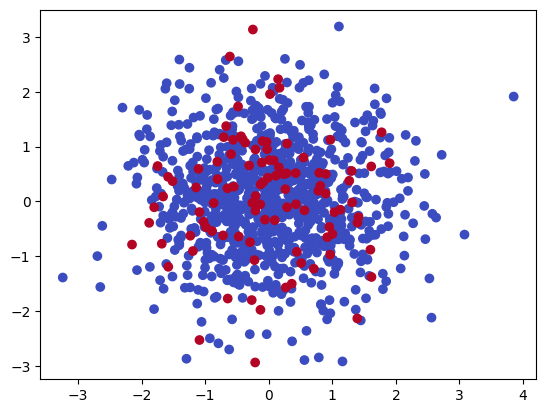

In [48]:
import matplotlib.pyplot as plt
plt.scatter(x=df["feature_1"],y=df["feature_2"], c=df["target"], cmap="coolwarm" ) # c -> noktaların rengi

In [ ]:
from imblearn.over_sampling import SMOTE # smote kullanmak için gerekli "imblearn" kütüphanesini aktif etmeliyiz!

In [34]:
oversample = SMOTE() # smote class'ından bir obje oluşturdum "oversample". bunu kullanarak işlemler yapacağız!

In [ ]:
(X,y) = oversample.fit_resample(df[["feature_1","feature_2"]],df["target"])

# Bu yazım önemli dikkat et unutulmasın!

In [36]:
X

,feature_1,feature_2
0,0.496714,0.368673
1,-0.138264,-0.393339
2,0.647689,0.028745
3,1.523030,1.278452
4,-0.234153,0.191099
...,...,...
1795,0.701868,-0.173309
1796,1.545917,-1.335943
1797,1.358114,-0.225781
1798,0.486916,-0.147628


In [37]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1795    1
1796    1
1797    1
1798    1
1799    1
Name: target, Length: 1800, dtype: int64

In [38]:
type(X)

pandas.core.frame.DataFrame

In [49]:
oversample_df = pd.concat([X,y], axis=1) # axis = 1 ile sütun bazlı birleştirme işlemi

In [40]:
oversample_df

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
1795,0.701868,-0.173309,1
1796,1.545917,-1.335943,1
1797,1.358114,-0.225781,1
1798,0.486916,-0.147628,1


In [41]:
# Görüldüğü üzere 'SMOTE' kullanarak upsample işlemi yapmış olduk!

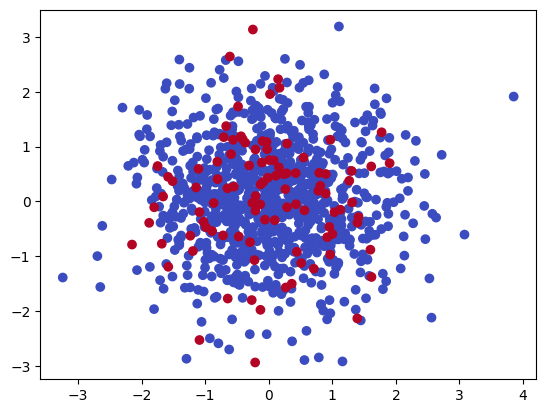

In [54]:
plt.scatter(df["feature_1"],df["feature_2"], c=df["target"], cmap="coolwarm")

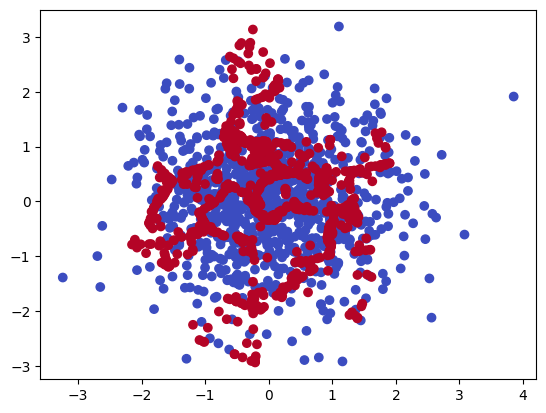

In [52]:
plt.scatter(oversample_df["feature_1"],oversample_df["feature_2"], c=oversample_df["target"], cmap="coolwarm")

In [50]:
# SMOTE İLE BENZER DATALAR KULLANARAK UPSAMPLE İŞLEMİ YAPMIŞ OLUYORUZ! DENGESİZ BİR DATA VARSA VE UPSAMPLE YAPACAKSAK SMOTE KULLANMAK İYİDİR!!!!!

# Amaç: Azınlık sınıfını tekrar etmek yerine, yapay yeni örnekler üretmek.
# Böylece model overfitting riskini azaltır.